# Olist E-Commerce Sentiment Analysis & Topic Modeling

This notebook presents an end-to-end Natural Language Processing (NLP) pipeline applied to the Olist e-commerce dataset.

The objective is to:

- Build a **Deep Learning-based Sentiment Analysis model**
- Extract **Customer Experience Topics** using Topic Modeling
- Generate business-ready features such as:
  - `sentiment_proba`
  - `sentiment_pred`
  - `sentiment_label`
  - `top_topic`
- Store results into a SQL database for dashboard integration

---

## Business Objectives

- Identify drivers of customer satisfaction
- Detect operational risks (e.g., fulfillment failures)
- Quantify customer perception by topic
- Enable revenue & sentiment cross-analysis in Power BI

---

## Notebook Structure

0. Setup  
1. Sentiment Analysis  
   - 1.1 Data Access & Cleaning  
   - 1.2 Tokenization & Preprocessing  
   - 1.3 Deep Learning Model  
2. Topic Modeling (NMF)  
3. Database Upload & Integration 

## 0. Setup

This section loads the required Python libraries and establishes a connection to the MySQL database.

The project follows the pipeline:

SQL → Python → ML → SQL → Power BI

All necessary NLP, machine learning, and database libraries are initialized here.

In [148]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Embedding, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import LearningRateScheduler
import pymysql
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import itertools
import unicodedata
import re

pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

## 1. Sentiment Analysis

### Objective

To classify customer reviews as **positive** or **negative** using a Deep Learning approach.

The model generates:

- `sentiment_proba` → Probability of positive sentiment
- `sentiment_pred` → Binary prediction (0 / 1)
- `sentiment_label` → Human-readable label

This enables quantitative measurement of customer perception.

### 1.1 Accessing and Cleaning Data

Customer review data is retrieved from the analytical base (`v_order_fact`).

Cleaning steps include:

- Removing null reviews
- Normalizing text
- Lowercasing
- Removing punctuation and noise

This ensures high-quality input for the NLP pipeline.

In [354]:
## SQL Connection
conn = pymysql.connect(database = "olist", user = "root", password = "160510", local_infile=True)
cursor = conn.cursor()

In [10]:
df_all = pd.read_sql("SELECT * FROM v_order_fact", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_7964\4161294256.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql("SELECT * FROM v_order_fact", conn)


In [11]:
df_all.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0000,0,58.9000,13.2900,72.1900,1.0000,72.1900,1.0000,2.0000,0.0000,5.0000,,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff\r,cool_stuff\r,1.0000,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0000,0,239.9000,19.9300,259.8300,1.0000,259.8300,1.0000,3.0000,0.0000,4.0000,,,2017-05-13 00:00:00,pet_shop\r,pet_shop\r,1.0000,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.0000,0,199.0000,17.8700,216.8700,1.0000,216.8700,1.0000,5.0000,0.0000,5.0000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor\r,furniture_decor\r,1.0000,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0000,0,12.9900,12.7900,25.7800,1.0000,25.7800,1.0000,2.0000,0.0000,4.0000,,,2018-08-15 00:00:00,perfumery\r,perfumery\r,1.0000,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0000,0,199.9000,18.1400,218.0400,1.0000,218.0400,1.0000,3.0000,0.0000,5.0000,,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools\r,garden_tools\r,1.0000,Single,garden_tools\r,varzea paulista,SP


In [20]:
def data_prep(data):
    df = data[["order_id", "review_score", "review_comment_message"]].copy()
    df = df.loc[~(df["review_score"]==3),:].copy()
    df.dropna(inplace=True)
    df=df.loc[~(df["review_comment_message"] == ""),:].copy()
    return df

In [22]:
df = data_prep(df_all)
df.head()

,order_id,review_score,review_comment_message
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,"Perfeito, produto entregue antes do combinado."
2,000229ec398224ef6ca0657da4fc703e,5.0000,Chegou antes do prazo previsto e o produto sur...
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,Gostei pois veio no prazo determinado .
8,0005a1a1728c9d785b8e2b08b904576c,1.0000,Na descrição do produto quando fui efetuar a c...
10,00061f2a7bc09da83e415a52dc8a4af1,5.0000,A caixa do produto veio com uma pequena avaria...


In [24]:
## normalization and lemmatization
def normalize_text(text):
    text = text.lower()
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

def token_lemma_nonstop(text):
    doc = nlp(text)
    output = [token.lemma_ for token in doc if not token.is_stop]
    output = ' '.join(output)
    return output

nlp = spacy.load("pt_core_news_sm") # Portuguese

In [26]:
df["clean_message"] = df["review_comment_message"].apply(normalize_text)
df["clean_message"] = df["clean_message"].apply(token_lemma_nonstop)

df.head()

,order_id,review_score,review_comment_message,clean_message
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,"Perfeito, produto entregue antes do combinado.",perfeito produto entregar combinado
2,000229ec398224ef6ca0657da4fc703e,5.0000,Chegou antes do prazo previsto e o produto sur...,chegar prazo prever produto surpreender qualid...
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,Gostei pois veio no prazo determinado .,gostar vir prazo determinar
8,0005a1a1728c9d785b8e2b08b904576c,1.0000,Na descrição do produto quando fui efetuar a c...,descricao produto efetuar compra detalhado pen...
10,00061f2a7bc09da83e415a52dc8a4af1,5.0000,A caixa do produto veio com uma pequena avaria...,caixa produto vir pequeno avariacao resto vir ...


In [27]:
def target(x):
    if x == 5 or x == 4:
        return 1
    else:
        return 0

In [28]:
df["target"] = df["review_score"].apply(target)
df.head()

,order_id,review_score,review_comment_message,clean_message,target
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,"Perfeito, produto entregue antes do combinado.",perfeito produto entregar combinado,1
2,000229ec398224ef6ca0657da4fc703e,5.0000,Chegou antes do prazo previsto e o produto sur...,chegar prazo prever produto surpreender qualid...,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,Gostei pois veio no prazo determinado .,gostar vir prazo determinar,1
8,0005a1a1728c9d785b8e2b08b904576c,1.0000,Na descrição do produto quando fui efetuar a c...,descricao produto efetuar compra detalhado pen...,0
10,00061f2a7bc09da83e415a52dc8a4af1,5.0000,A caixa do produto veio com uma pequena avaria...,caixa produto vir pequeno avariacao resto vir ...,1


In [59]:
target = df["target"].values.tolist()
data = df["clean_message"].values.tolist()

In [61]:
## train test

cutoff = int(len(data)*0.80)
x_train,x_test=data[:cutoff], data[cutoff:]
y_train, y_test=target[:cutoff], target[cutoff:]

### 1.2 Tokenization and Data Preprocessing

Text preprocessing includes:

- Tokenization
- Vocabulary selection (Top 10,000 most frequent words)
- Sequence transformation
- Padding to fixed length

The resulting sequences are used as input to a Recurrent Neural Network (GRU).

This step converts unstructured text into structured numerical input suitable for deep learning.

In [214]:
def tokenization(df, num_words=10000, train_test=False):

    target = df["target"].values.tolist()
    data = df["clean_message"].values.tolist()

    if train_test:

        cutoff = int(len(data)*0.80)
        x_train,x_test=data[:cutoff], data[cutoff:]
        y_train, y_test=target[:cutoff], target[cutoff:]
    
        num_words=num_words
        tokenizer = Tokenizer(num_words=num_words)
        tokenizer.fit_on_texts(data)
        x_train_tokens=tokenizer.texts_to_sequences(x_train)
        x_test_tokens=tokenizer.texts_to_sequences(x_test)
    
        # Number of tokens per comment
        num_tokens=[len(tokens) for tokens in x_train_tokens + x_test_tokens]
        num_tokens = np.array(num_tokens)
    
        # We will process the size of all comments by applying padding.
        max_tokens=np.mean(num_tokens) + 2 * np.std(num_tokens)
        max_tokens=int(max_tokens)
    
        x_train_pad=pad_sequences(x_train_tokens, maxlen=max_tokens)
        x_test_pad=pad_sequences(x_test_tokens, maxlen=max_tokens)
    
        idx = tokenizer.word_index
        inverse_map = dict(zip(idx.values(), idx.keys()))
    
        return x_train_tokens, x_test_tokens, x_train_pad, x_test_pad, idx, inverse_map, num_words, max_tokens
    else:

        num_words=num_words
        tokenizer = Tokenizer(num_words=num_words)
        tokenizer.fit_on_texts(data)

        x_all = data

        x_all_tokens=tokenizer.texts_to_sequences(x_all)
        # Number of tokens per comment
        num_tokens=[len(tokens) for tokens in x_all_tokens]
        num_tokens = np.array(num_tokens)

        # We will process the size of all comments by applying padding.
        max_tokens=np.mean(num_tokens) + 2 * np.std(num_tokens)
        max_tokens=int(max_tokens)

        x_all_pad=pad_sequences(x_all_tokens, maxlen=max_tokens)

        idx = tokenizer.word_index
        inverse_map = dict(zip(idx.values(), idx.keys()))

        return x_all_tokens, x_all_pad, idx, inverse_map, num_words, max_tokens

In [216]:
x_train_tokens, x_test_tokens, x_train_pad, x_test_pad, idx, inverse_map, num_words, max_tokens = tokenization(df, num_words=10000, train_test=True)

In [217]:
def tokens_to_string(tokens):
    words = [inverse_map[token] for token in tokens if token!=0]
    text=" ".join(words)
    return text

In [218]:
tokens_to_string(x_train_tokens[255])

'produto otima qualidade entrega super rapir'

In [219]:
x_train_tokens[255]

[1, 232, 11, 8, 23, 14]

### 1.3 Deep Learning Model

A GRU-based Recurrent Neural Network is used for sentiment classification.

Architecture:
- Embedding layer
- Stacked GRU layers
- Sigmoid output layer

Loss Function: Binary Crossentropy  
Optimizer: Adam  
Metric: Accuracy  

The model outputs a probability score representing customer sentiment intensity.

In [225]:
model=Sequential()

embedding_size=50

model.add(Embedding(input_dim=num_words,
                   output_dim=embedding_size,
                   input_length=max_tokens,
                    mask_zero=True,
                   name="embedding_layer"))

model.add(GRU(units=16, return_sequences=True))
model.add(GRU(units=8, return_sequences=True))
model.add(GRU(units=4))
model.add(Dense(1, activation="sigmoid"))

optimizer = Adam(learning_rate=0.001)

model.compile(loss="binary_crossentropy",
             optimizer=optimizer,
             metrics=["accuracy"])

C:\Users\okand\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [227]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_6 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_7 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_8 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [229]:
history = model.fit(np.array(x_train_pad), np.array(y_train), epochs=5, batch_size=256)

Epoch 1/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.7724 - loss: 0.5546
Epoch 2/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9142 - loss: 0.2866
Epoch 3/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9359 - loss: 0.2278
Epoch 4/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9497 - loss: 0.1844
Epoch 5/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9541 - loss: 0.1720


In [230]:
result=model.evaluate(np.array(x_test_pad), np.array(y_test))

232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9136 - loss: 0.2691


In [231]:
result[1] # test accuracy

0.910538375377655

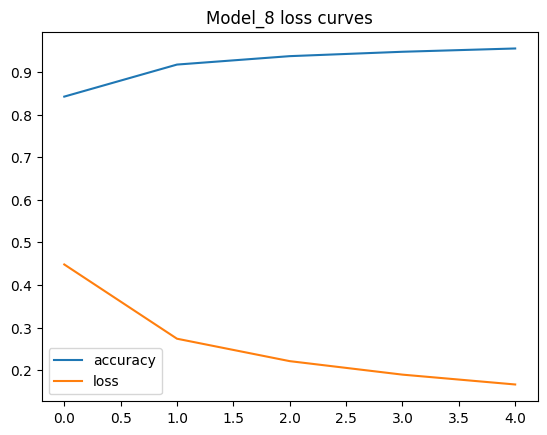

In [232]:
# Plot the loss curves

pd.DataFrame(history.history).plot()
plt.title("Model_8 loss curves");

In [233]:
y_preds = model.predict(np.array(x_test_pad))
y_preds = y_preds.T[0]

232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [234]:
cls_pred=np.array([1.0 if p > 0.5 else 0.0 for p in y_preds])
cls_true=np.array(y_test)

In [235]:
incorrect=np.where(cls_pred!=cls_true)
incorrect=incorrect[0]

In [236]:
len(incorrect)

663

In [237]:
len(cls_true)

7411

In [238]:
len(incorrect) / len(cls_true)

0.08946161111860748

In [239]:
idx=incorrect[0]
idx

23

In [240]:
text=x_test[idx]
text

'produto chegar raper por conectar tomada acender luz por conectar algum adaptador luz enfraquecer aparelho naoer funcionar'

In [241]:
y_preds[idx]

0.9744744

In [242]:
cls_true[idx]

0

In [243]:
def conf_matrix_plot(y_test, y_pred):
    figsize = (10,10)

    # Create the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize our confusion matrix
    n_classes = cm.shape[0]
    
    # Let's prettify it
    fig, ax = plt.subplots(figsize = figsize)
    # Create matrix plot
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)
    
    # Create classes
    classes = False
    
    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])
    
    # Label the axes
    ax.set(title = "Confusion Matrix",
          xlabel = "Predicted Label",
          ylabel = "True Label",
          xticks = np.arange(n_classes),
          yticks = np.arange(n_classes),
          xticklabels = labels,
          yticklabels = labels)
    
    # Set x-axis labels to bottom
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()
    
    #Adjust label size
    ax.yaxis.label.set_size(20)
    ax.xaxis.label.set_size(20)
    ax.title.set_size(20)
    
    # set threshold for different colors
    threshold = (cm.max() + cm.min()) / 2.
    
    # Plot the text on each cell
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j,i, f"{cm[i,j]} ({cm_norm[i,j]*100:.1f}%)",
                horizontalalignment ="center",
                color = "white" if cm[i,j] > threshold else "black",
                size=15)

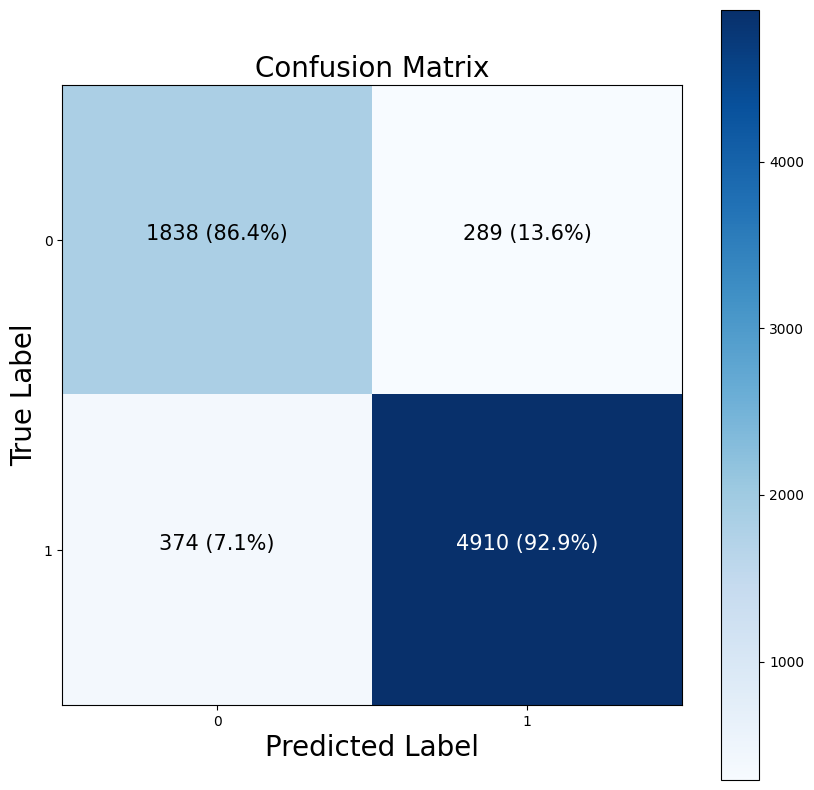

In [244]:
conf_matrix_plot(y_test, cls_pred)

Let's find the threshold value based on the f1 score:

In [246]:
proba_test = model.predict(np.array(x_test_pad), batch_size=256).ravel()

thresholds = np.linspace(0.1, 0.9, 81)
f1s = [f1_score(y_test, (proba_test >= t).astype(int)) for t in thresholds]

best_t = thresholds[int(np.argmax(f1s))]
best_t

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


0.4

In [247]:
cls_pred_2=np.array([1.0 if p > best_t else 0.0 for p in y_preds])

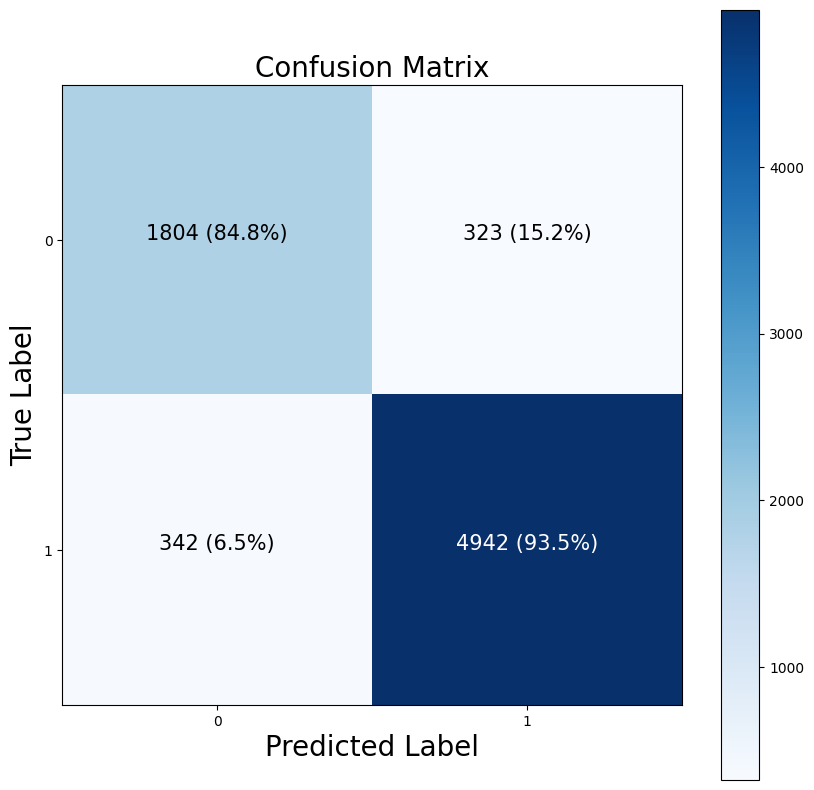

In [248]:
conf_matrix_plot(y_test, cls_pred_2)

Let's apply the model to all the comments in our dataset:

In [273]:
df_text=df_all[["order_id", "review_score", "review_comment_message"]].copy()
df_text.dropna(inplace=True)
df_text=df_text.loc[~(df_text["review_comment_message"] == ""),:].copy()
df_text.head()

,order_id,review_score,review_comment_message
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,"Perfeito, produto entregue antes do combinado."
2,000229ec398224ef6ca0657da4fc703e,5.0000,Chegou antes do prazo previsto e o produto sur...
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,Gostei pois veio no prazo determinado .
8,0005a1a1728c9d785b8e2b08b904576c,1.0000,Na descrição do produto quando fui efetuar a c...
10,00061f2a7bc09da83e415a52dc8a4af1,5.0000,A caixa do produto veio com uma pequena avaria...


In [275]:
df_text["clean_message"] = df_text["review_comment_message"].apply(normalize_text)
df_text["clean_message"] = df_text["clean_message"].apply(token_lemma_nonstop)
df_text.head()

,order_id,review_score,review_comment_message,clean_message
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,"Perfeito, produto entregue antes do combinado.",perfeito produto entregar combinado
2,000229ec398224ef6ca0657da4fc703e,5.0000,Chegou antes do prazo previsto e o produto sur...,chegar prazo prever produto surpreender qualid...
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,Gostei pois veio no prazo determinado .,gostar vir prazo determinar
8,0005a1a1728c9d785b8e2b08b904576c,1.0000,Na descrição do produto quando fui efetuar a c...,descricao produto efetuar compra detalhado pen...
10,00061f2a7bc09da83e415a52dc8a4af1,5.0000,A caixa do produto veio com uma pequena avaria...,caixa produto vir pequeno avariacao resto vir ...


In [284]:
df_text["review_score"].dtype

dtype('float64')

In [286]:
def make_target(x):
    return 1 if x in (4, 5) else 0

df_text["target"] = df_text["review_score"].apply(make_target)

In [288]:
x_all_tokens, x_all_pad, idx, inverse_map, num_words, max_tokens = tokenization(df_text, num_words=10000, train_test=False)

In [292]:
proba = model.predict(np.array(x_all_pad), batch_size=256).ravel()

df_text["sentiment_proba"] = proba
df_text["sentiment_pred"] = (df_text["sentiment_proba"] >= best_t).astype(int)
df_text["sentiment_label"] = np.where(df_text["sentiment_pred"] == 1, "positive", "negative")

159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


In [294]:
df_text.head()

,order_id,review_score,review_comment_message,clean_message,target,sentiment_proba,sentiment_pred,sentiment_label
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,"Perfeito, produto entregue antes do combinado.",perfeito produto entregar combinado,1,0.9752,1,positive
2,000229ec398224ef6ca0657da4fc703e,5.0000,Chegou antes do prazo previsto e o produto sur...,chegar prazo prever produto surpreender qualid...,1,0.9726,1,positive
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,Gostei pois veio no prazo determinado .,gostar vir prazo determinar,1,0.9724,1,positive
8,0005a1a1728c9d785b8e2b08b904576c,1.0000,Na descrição do produto quando fui efetuar a c...,descricao produto efetuar compra detalhado pen...,0,0.9754,1,positive
10,00061f2a7bc09da83e415a52dc8a4af1,5.0000,A caixa do produto veio com uma pequena avaria...,caixa produto vir pequeno avariacao resto vir ...,1,0.0738,0,negative


## 2. Topic Modeling

### Objective

To uncover hidden themes in customer reviews using Non-Negative Matrix Factorization (NMF).

Unlike sentiment analysis (which measures polarity), topic modeling identifies:

- Delivery execution issues
- Product satisfaction
- Fulfillment failures
- On-time arrival performance
- Store advocacy

TF-IDF vectorization is applied before NMF to extract meaningful topic-word structures.

Each review is assigned:
- Topic probabilities
- Dominant topic label

In [300]:
stopwords_pt = nlp.Defaults.stop_words
stopwords_pt_list = list(stopwords_pt)

In [304]:
tv2 = TfidfVectorizer(stop_words=stopwords_pt_list, min_df=20 ,max_df=0.7, ngram_range=(1,2))
# It should appear in at least 20 documents.
# It should appear in a maximum of 70% of the documents.
Xt2 = tv2.fit_transform(df_text["clean_message"].astype(str))
Xt_df2 = pd.DataFrame(Xt2.toarray(), columns = tv2.get_feature_names_out())
Xt_df2.head()

01     02     03     10  10 dia    100   1000     11     12     14  \
0 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
1 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
2 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
3 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
4 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   

      15  15 dia     16     17     20  20 dia     24     25     30  30 dia  \
0 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000   
1 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000   
2 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000   
3 0.3752  0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000   
4 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000   

      40     48  48 hora     50     60  abaixo  abraco   abri  abrir  absurdo  \
0 0.0000 0.0000   0.0000 0.0000 0.0000  0.0000  0.0000 0.0000 0.0000   0.0000   
1 0.0000 0.0000   0.0000 0.0000 0.0000  0.0000  0.0000 0.0000 0.0000   0.0000   
2 0.0000 0.0000   0.0000 0.0000 0.0000  0.0000  0.0000 0.0000 0.0000   0.0000   
3 0.0000 0.0000   0.0000 0.0000 0.0000  0.0000  0.0000 0.0000 0.0000   0.0000   
4 0.0000 0.0000   0.0000 0.0000 0.0000  0.0000  0.0000 0.0000 0.0000   0.0000   

   acabamento  acabar  aceitar  acessivel  achar  achar demorar  achar dever  \
0      0.0000  0.0000   0.0000     0.0000 0.0000         0.0000       0.0000   
1      0.0000  0.0000   0.0000     0.0000 0.0000         0.0000       0.0000   
2      0.0000  0.0000   0.0000     0.0000 0.0000         0.0000       0.0000   
3      0.0000  0.0000   0.0000     0.0000 0.0000         0.0000       0.0000   
4      0.0000  0.0000   0.0000     0.0000 0.0000         0.0000       0.0000   

   achar frete  achar pequeno  achar produto  acima  acompanhamento  \
0       0.0000         0.0000         0.0000 0.0000          0.0000   
1       0.0000         0.0000         0.0000 0.0000          0.0000   
2       0.0000         0.0000         0.0000 0.0000          0.0000   
3       0.0000         0.0000         0.0000 0.0000          0.0000   
4       0.0000         0.0000         0.0000 0.0000          0.0000   

   acompanhar  acondicionar  acontecer  acordar  acordo  acordo descricao  \
0      0.0000        0.0000     0.0000   0.0000  0.0000            0.0000   
1      0.0000        0.0000     0.0000   0.0000  0.0000            0.0000   
2      0.0000        0.0000     0.0000   0.0000  0.0000            0.0000   
3      0.0000        0.0000     0.0000   0.0000  0.0000            0.0000   
4      0.0000        0.0000     0.0000   0.0000  0.0000            0.0000   

   acreditar  adequado  adesivo  adiantar   ador  adorar  adorar compra  \
0     0.0000    0.0000   0.0000    0.0000 0.0000  0.0000         0.0000   
1     0.0000    0.0000   0.0000    0.0000 0.0000  0.0000         0.0000   
2     0.0000    0.0000   0.0000    0.0000 0.0000  0.0000         0.0000   
3     0.0000    0.0000   0.0000    0.0000 0.0000  0.0000         0.0000   
4     0.0000    0.0000   0.0000    0.0000 0.0000  0.0000         0.0000   

   adorar comprar  adorar produto  adorei  adquirir  adquirir produto  \
0          0.0000          0.0000  0.0000    0.0000            0.0000   
1          0.0000          0.0000  0.0000    0.0000            0.0000   
2          0.0000          0.0000  0.0000    0.0000            0.0000   
3          0.0000          0.0000  0.0000    0.0000            0.0000   
4          0.0000          0.0000  0.0000    0.0000            0.0000   

   agencia  agencia correio   agil  agilidade  agilidade entrega  agilidader  \
0   0.0000           0.0000 0.0000     0.0000             0.0000      0.0000   
1   0.0000           0.0000 0.0000     0.0000             0.0000      0.0000   
2   0.0000           0.0000 0.0000     0.0000             0.0000      0.0000   
3   0.0000  

In [306]:
nmf = NMF(n_components=5, random_state=42, max_iter=500)
W = nmf.fit_transform(Xt_df2) # documents-topics
H = nmf.components_ # topics-terms

In [308]:
from deep_translator import GoogleTranslator

translator = GoogleTranslator(source='pt', target='en')

def display_topics(H, num_words=10):
    for topic_num, topic_array in enumerate(H):
        top_features = topic_array.argsort()[::-1][:num_words]
        top_words_pt = [tv2.get_feature_names_out()[i] for i in top_features]

        top_words_en = [translator.translate(word) for word in top_words_pt]
        
        print("Topic", topic_num+1, ":", ", ".join(top_words_en))

In [310]:
display_topics(H)

Topic 1 : deliver, deliver deadline, term, product deliver, product, rapir, deliver quickly, excellent, quality, not deliver
Topic 2 : excellent, great product, product, great product, great quality, quality, great store, service, rapir, great purchase
Topic 3 : no, product, I received, I didn't receive it, I received product, product no, until, I bought, not deliver, come
Topic 4 : to arrive, arrive deadline, term, product arrive, product, delivery, predict, recommend, not arrive, excellent
Topic 5 : recommend, store, deadline recommend, recommend store, excellent, product recommend, recommend product, quality, to like, quality recommend


In [312]:
doc_topics = pd.DataFrame(W)
doc_topics.columns = ["Delivery Execution", "Product Satisfaction", "Fulfillment Failure", "On-Time Arrival", "Store Advocacy"]
doc_topics.head()

,Delivery Execution,Product Satisfaction,Fulfillment Failure,On-Time Arrival,Store Advocacy
0,0.0389,0.0005,0.0078,0.0000,0.0003
1,0.0042,0.0022,0.0012,0.0763,0.0003
2,0.0099,0.0000,0.0029,0.0192,0.0011
3,0.0027,0.0019,0.0392,0.0050,0.0005
4,0.0021,0.0010,0.0162,0.0081,0.0009


In [314]:
df_text = df_text.reset_index(drop=True)
doc_topics = doc_topics.reset_index(drop=True)

df_text = pd.concat([df_text, doc_topics], axis=1)

In [316]:
df_text.head()

,order_id,review_score,review_comment_message,clean_message,target,sentiment_proba,sentiment_pred,sentiment_label,Delivery Execution,Product Satisfaction,Fulfillment Failure,On-Time Arrival,Store Advocacy
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,"Perfeito, produto entregue antes do combinado.",perfeito produto entregar combinado,1,0.9752,1,positive,0.0389,0.0005,0.0078,0.0000,0.0003
1,000229ec398224ef6ca0657da4fc703e,5.0000,Chegou antes do prazo previsto e o produto sur...,chegar prazo prever produto surpreender qualid...,1,0.9726,1,positive,0.0042,0.0022,0.0012,0.0763,0.0003
2,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,Gostei pois veio no prazo determinado .,gostar vir prazo determinar,1,0.9724,1,positive,0.0099,0.0000,0.0029,0.0192,0.0011
3,0005a1a1728c9d785b8e2b08b904576c,1.0000,Na descrição do produto quando fui efetuar a c...,descricao produto efetuar compra detalhado pen...,0,0.9754,1,positive,0.0027,0.0019,0.0392,0.0050,0.0005
4,00061f2a7bc09da83e415a52dc8a4af1,5.0000,A caixa do produto veio com uma pequena avaria...,caixa produto vir pequeno avariacao resto vir ...,1,0.0738,0,negative,0.0021,0.0010,0.0162,0.0081,0.0009


In [320]:
df_text["top_topic"] = df_text.iloc[:, 8:].idxmax(axis=1)
df_text.head()

,order_id,review_score,review_comment_message,clean_message,target,sentiment_proba,sentiment_pred,sentiment_label,Delivery Execution,Product Satisfaction,Fulfillment Failure,On-Time Arrival,Store Advocacy,top_topic
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,"Perfeito, produto entregue antes do combinado.",perfeito produto entregar combinado,1,0.9752,1,positive,0.0389,0.0005,0.0078,0.0000,0.0003,Delivery Execution
1,000229ec398224ef6ca0657da4fc703e,5.0000,Chegou antes do prazo previsto e o produto sur...,chegar prazo prever produto surpreender qualid...,1,0.9726,1,positive,0.0042,0.0022,0.0012,0.0763,0.0003,On-Time Arrival
2,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,Gostei pois veio no prazo determinado .,gostar vir prazo determinar,1,0.9724,1,positive,0.0099,0.0000,0.0029,0.0192,0.0011,On-Time Arrival
3,0005a1a1728c9d785b8e2b08b904576c,1.0000,Na descrição do produto quando fui efetuar a c...,descricao produto efetuar compra detalhado pen...,0,0.9754,1,positive,0.0027,0.0019,0.0392,0.0050,0.0005,Fulfillment Failure
4,00061f2a7bc09da83e415a52dc8a4af1,5.0000,A caixa do produto veio com uma pequena avaria...,caixa produto vir pequeno avariacao resto vir ...,1,0.0738,0,negative,0.0021,0.0010,0.0162,0.0081,0.0009,Fulfillment Failure


## Topic Interpretation

| Topic | Title | Business Meaning |
|--------|--------|----------------|
| 1 | Delivery Execution | Logistics performance quality |
| 2 | Product Satisfaction | Product perception & quality |
| 3 | Fulfillment Failure | Operational breakdown risk |
| 4 | On-Time Arrival | Delivery punctuality experience |
| 5 | Store Advocacy | Brand trust & customer loyalty |

These topics allow us to connect operational performance with customer perception.

## Sentiment by Topic

Cross-analysis between topic distribution and sentiment probability enables:

- Identification of high-risk operational areas
- Detection of churn-driving themes
- Measurement of satisfaction drivers

This transforms raw review text into structured business intelligence.

In [337]:
df_text.groupby("top_topic")["sentiment_proba"].mean().sort_values(ascending=False)

top_topic
Product Satisfaction   0.9474
On-Time Arrival        0.8105
Store Advocacy         0.7864
Delivery Execution     0.7309
Fulfillment Failure    0.5762
Name: sentiment_proba, dtype: float32

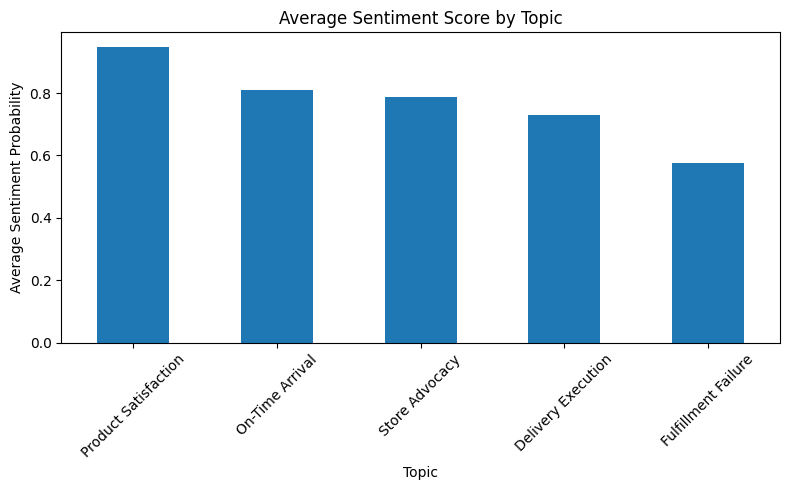

In [339]:
topic_sent = (
    df_text.groupby("top_topic")["sentiment_proba"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
topic_sent.plot(kind="bar")

plt.title("Average Sentiment Score by Topic")
plt.ylabel("Average Sentiment Probability")
plt.xlabel("Topic")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [325]:
pd.crosstab(df_text["top_topic"], df_text["sentiment_label"], normalize="index")

sentiment_label,negative,positive
top_topic,,
Delivery Execution,0.1457,0.8543
Fulfillment Failure,0.4109,0.5891
On-Time Arrival,0.1445,0.8555
Product Satisfaction,0.0145,0.9855
Store Advocacy,0.1314,0.8686


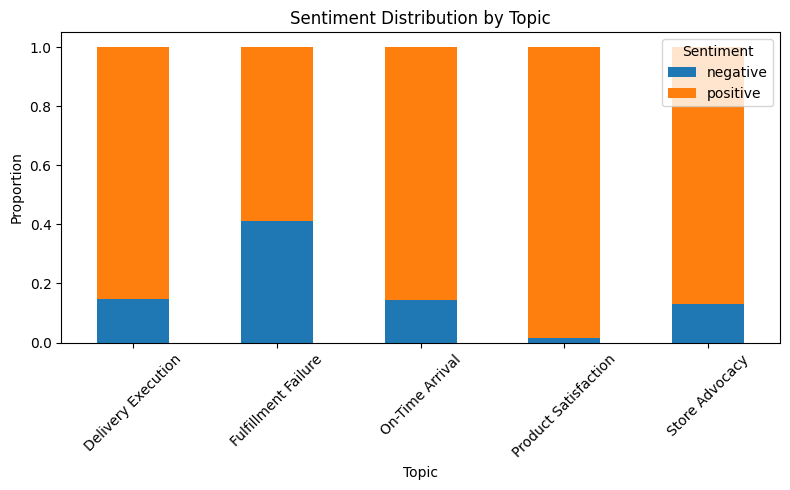

In [331]:
ct = pd.crosstab(
    df_text["top_topic"],
    df_text["sentiment_label"],
    normalize="index"
)

ct.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Sentiment Distribution by Topic")
plt.ylabel("Proportion")
plt.xlabel("Topic")
plt.legend(title="Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Uploading to the Database

Final enriched dataset includes:

- Review metadata
- Sentiment metrics
- Topic probabilities
- Dominant topic classification

The dataset is exported and uploaded to MySQL for:

- Power BI dashboard integration
- Revenue × Sentiment analysis
- Operational performance tracking

In [344]:
df_text.to_csv("sentiment.csv", index=False)

In [346]:
df_text2 = pd.read_csv("sentiment.csv")
df_text2.head()

,order_id,review_score,review_comment_message,clean_message,target,sentiment_proba,sentiment_pred,sentiment_label,Delivery Execution,Product Satisfaction,Fulfillment Failure,On-Time Arrival,Store Advocacy,top_topic
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,"Perfeito, produto entregue antes do combinado.",perfeito produto entregar combinado,1,0.9752,1,positive,0.0389,0.0005,0.0078,0.0000,0.0003,Delivery Execution
1,000229ec398224ef6ca0657da4fc703e,5.0000,Chegou antes do prazo previsto e o produto sur...,chegar prazo prever produto surpreender qualid...,1,0.9726,1,positive,0.0042,0.0022,0.0012,0.0763,0.0003,On-Time Arrival
2,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,Gostei pois veio no prazo determinado .,gostar vir prazo determinar,1,0.9724,1,positive,0.0099,0.0000,0.0029,0.0192,0.0011,On-Time Arrival
3,0005a1a1728c9d785b8e2b08b904576c,1.0000,Na descrição do produto quando fui efetuar a c...,descricao produto efetuar compra detalhado pen...,0,0.9754,1,positive,0.0027,0.0019,0.0392,0.0050,0.0005,Fulfillment Failure
4,00061f2a7bc09da83e415a52dc8a4af1,5.0000,A caixa do produto veio com uma pequena avaria...,caixa produto vir pequeno avariacao resto vir ...,1,0.0738,0,negative,0.0021,0.0010,0.0162,0.0081,0.0009,Fulfillment Failure


In [350]:
q_create_table = """
CREATE TABLE sentiment (
    order_id VARCHAR(32) NOT NULL PRIMARY KEY,
    review_score TINYINT NOT NULL,
    review_comment_message TEXT,
    clean_message TEXT,
    target TINYINT,
    sentiment_proba FLOAT,
    sentiment_pred TINYINT,
    sentiment_label VARCHAR(10),
    delivery_execution FLOAT,
    product_satisfaction FLOAT,
    fulfillment_failure FLOAT,
    on_time_arrival FLOAT,
    store_advocacy FLOAT,
    top_topic VARCHAR(50)
);
"""

cursor.execute(q_create_table)
conn.commit()

In [356]:
q_load_data = """
LOAD DATA LOCAL INFILE 'C:/Users/okand/Desktop/ecommerce/sentiment.csv'
INTO TABLE sentiment
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS
(order_id, review_score, review_comment_message, clean_message,
 target, sentiment_proba, sentiment_pred, sentiment_label,
 delivery_execution, product_satisfaction,
 fulfillment_failure, on_time_arrival,
 store_advocacy, top_topic);
"""

cursor.execute(q_load_data)
conn.commit()

In [360]:
pd.read_sql("SELECT * FROM sentiment LIMIT 10;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_7964\3958342802.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM sentiment LIMIT 10;", conn)


,order_id,review_score,review_comment_message,clean_message,target,sentiment_proba,sentiment_pred,sentiment_label,delivery_execution,product_satisfaction,fulfillment_failure,on_time_arrival,store_advocacy,top_topic
0,00010242fe8c5a6d1ba2dd792cb16214,5,"Perfeito, produto entregue antes do combinado.",perfeito produto entregar combinado,1,0.9752,1,positive,0.0389,0.0005,0.0078,0.0000,0.0003,Delivery Execution\r
1,000229ec398224ef6ca0657da4fc703e,5,Chegou antes do prazo previsto e o produto sur...,chegar prazo prever produto surpreender qualid...,1,0.9726,1,positive,0.0042,0.0022,0.0012,0.0763,0.0003,On-Time Arrival\r
2,00042b26cf59d7ce69dfabb4e55b4fd9,5,Gostei pois veio no prazo determinado .,gostar vir prazo determinar,1,0.9724,1,positive,0.0099,0.0000,0.0029,0.0192,0.0011,On-Time Arrival\r
3,0005a1a1728c9d785b8e2b08b904576c,1,Na descrição do produto quando fui efetuar a c...,descricao produto efetuar compra detalhado pen...,0,0.9754,1,positive,0.0027,0.0019,0.0392,0.0050,0.0005,Fulfillment Failure\r
4,00061f2a7bc09da83e415a52dc8a4af1,5,A caixa do produto veio com uma pequena avaria...,caixa produto vir pequeno avariacao resto vir ...,1,0.0738,0,negative,0.0021,0.0010,0.0162,0.0081,0.0009,Fulfillment Failure\r
5,00063b381e2406b52ad429470734ebd5,5,"Fiquei um pouco triste, achei que a cor do cor...",fiquei triste achar cor coracao verde conforme...,1,0.1194,0,negative,0.0000,0.0000,0.0173,0.0001,0.0001,Fulfillment Failure\r
6,0006ec9db01a64e59a68b2c340bf65a7,5,Excelente serviço de compras on line.,excelente servico compra on line,1,0.9756,1,positive,0.0033,0.0014,0.0024,0.0043,0.0047,Store Advocacy\r
7,000aed2e25dbad2f9ddb70584c5a2ded,1,Mudo minha opinião assim que receber o produto...,mudo opiniao receber produto \r\n constar site...,0,0.6219,1,positive,0.0215,0.0000,0.0641,0.0000,0.0000,Fulfillment Failure\r
8,000c3e6612759851cc3cbb4b83257986,5,Recebi td certinho antes do prazo!,recebi td certinho prazo,1,0.9722,1,positive,0.0091,0.0000,0.0202,0.0165,0.0000,Fulfillment Failure\r
9,000e562887b1f2006d75e0be9558292e,3,Bom produto,produto,0,0.8564,1,positive,0.0171,0.0116,0.0893,0.0293,0.0013,Fulfillment Failure\r


In [362]:
conn.close()

# Executive Summary

This project builds an end-to-end NLP analytics pipeline for e-commerce review data.

Key Achievements:

- Developed a GRU-based sentiment classification model
- Extracted customer experience themes using NMF
- Engineered production-ready features for BI integration
- Connected NLP outputs with structured SQL analytics

Business Impact:

- Identified operational risk areas (Fulfillment Failure)
- Quantified customer satisfaction drivers (Product Satisfaction)
- Enabled sentiment-based revenue analysis

This project demonstrates the integration of Machine Learning, NLP, and Business Intelligence in a production-ready workflow.